(sec:pes)=
# Potential energy surfaces

VeloxChem enables the exploration of potential energy surfaces through efficient geometry optimizations and transition‑state searches, using the [geomeTRIC](https://pypi.org/project/geometric/) module as a robust engine that provides stable structure updates for molecular systems.

(sec:GS-opt)=
## Ground state optimization

VeloxChem evaluates analytic ground‑state gradients and employs quasi‑Newton optimization algorithms that approximate the local Hessian to achieve rapid convergence toward a minimum. 

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("bithiophene")
molecule.set_dihedral_in_degrees([3, 4, 6, 10], 160)
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_drv.dispersion = True
results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, results)

Reading bithiophene from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct In

In [2]:
opt_molecule = vlx.Molecule.read_xyz_string(opt_results["final_geometry"])
opt_molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

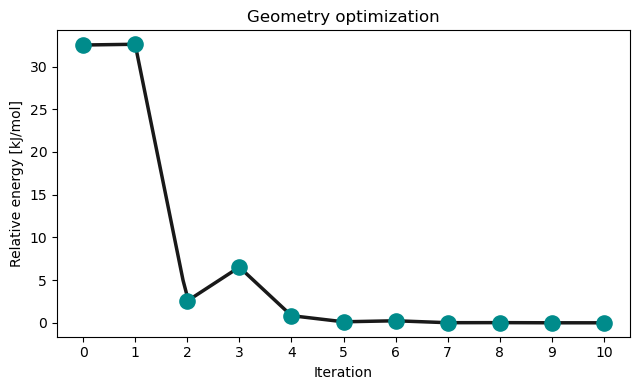

In [3]:
opt_drv.plot_convergence(opt_results)

**Text file**

Please refer to the [keyword list](#sec:opt-keywords) for a complete set of options. Dispersion can be activated in the `@method settings` section by using the keyword `dispersion`.

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
dispersion: yes # use dft-d4 correction
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

## Constrained optimization

Internal coordinates (distances, angles, dihedrals) can be constrained during the molecular structure optimization with use of either the `set`, `freeze`, or `scan` directives. 

(sec:freeze)=
### Set or freeze internal coordinate

The `set` directive will aim at converging an internal coordinate to a desired value while `freeze` will keep it at its initial value. 

**Python script**

In [4]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""4
Hydrogen peroxide
O  -0.65564532 -0.06106286 -0.03621403
O   0.65564532  0.06106286 -0.03621403
H  -0.97628735  0.65082652  0.57474201
H   0.97628735 -0.65082652  0.57474201
""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ["set dihedral 3 1 2 4 90.0", "freeze distance 1 2"]
opt_results = opt_drv.compute(molecule, basis, results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [5]:
molecule_opt = vlx.Molecule.read_xyz_string(opt_results['final_geometry'])
molecule_opt.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Text file**

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@optimize
constraints:
set dihedral 3 1 2 4 90.0
freeze distance 1 2 
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:scan)=
### Scan coordinate

The `scan` directive will perform a relaxed scan of an internal coordinate from an initial to a final value in a given number of steps. 

```
scan distance 6 1 1.4 1.5 9
scan angle    6 1 2 100 110 9
scan dihedral 6 1 2 3 0 360 19
```

**Python script**

In [6]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""4
Hydrogen peroxide
O  -0.65564532 -0.06106286 -0.03621403
O   0.65564532  0.06106286 -0.03621403
H  -0.97628735  0.65082652  0.57474201
H   0.97628735 -0.65082652  0.57474201
""")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ["scan dihedral 3 1 2 4 0 180 7"]
opt_results = opt_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

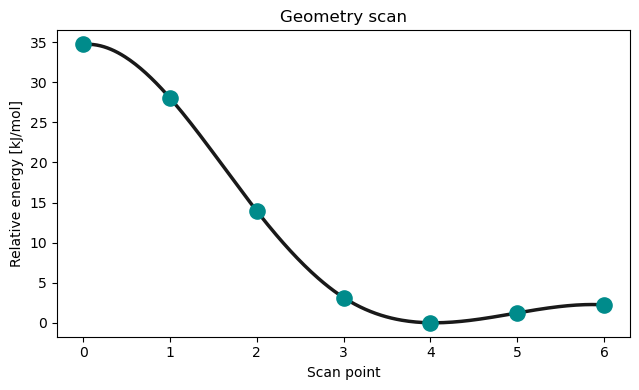

In [7]:
opt_drv.plot_scan(opt_results)

**Text file**

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@optimize
constraints:
scan dihedral 3 1 2 4 180 0 7
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:TS-opt)=
## Transition state optimization

Transition‑state optimization targets first‑order saddle points on the Born–Oppenheimer potential energy surface, characterized by vanishing gradients and a single imaginary Hessian eigenvalue. The resulting transition‑state geometry defines the critical point connecting reactant and product minima and provides the reference structure for calculating reaction pathways, activation energies, and vibrational signatures.

The optimization of a transition-state structure requires an initial guess of the structure that is close to the actual one. 

(sec:TS-guess)=
### Obtaining a start guess of the transition state structure

The transition-state guesser can be used to efficiently calculate an initial guess for a transition state structure. More information can be found in the [eChem book](https://kthpanor.github.io/echem/docs/mol_struct/ts_guesser.html)

**Python script**

In [1]:
import veloxchem as vlx

reac1 = vlx.Molecule.read_smiles("C=CO")
reac2 = vlx.Molecule.read_smiles("C=O")

prod = vlx.Molecule.read_smiles("C(=O)CCO")

ts_guesser = vlx.TransitionStateGuesser()
ts_guesser.do_qm_scan = True
ts_guess_results = ts_guesser.find_transition_state([reac1, reac2], prod)

* Info * Building forcefields. Disable mute_ff_build to see detailed output.                                              
                                                     Reaction summary                                                     
                                                    1 breaking bonds:                                                     
                                       ReaType  ProType  ID - ReaType  ProType  ID                                        
                                          oh        o    3  -    ho       ho    7                                         
                                                                                                                          
                                                     2 forming bonds:                                                     
                                       ReaType  ProType  ID - ReaType  ProType  ID                                        
                

In [9]:
ts_guess=vlx.Molecule.read_xyz_string(ts_guess_results['max_qm_xyz'])
ts_guess.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Optimizing the transition state structure

**Python script**

In [3]:
import veloxchem as vlx

ts_guess=vlx.Molecule.read_xyz_string(ts_guess_results['max_qm_xyz'])
basis = vlx.MolecularBasis.read(ts_guess, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "B3LYP"
scf_results = scf_drv.compute(ts_guess, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.transition = True
opt_results = opt_drv.compute(ts_guess, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

* Info * Starting Reduced Basis SCF calculation...                                                                        
* Info * ...done. SCF energy in reduced basis set: -266.348854125709 a.u. Time: 0.15 sec.                                 
                                                                                                                          
                                                                                                                          
               Iter. |    Kohn-Sham Energy | Energy Change | Gradient Norm | Max. Gradient | Density Change               
               --------------------------------------------------------------------------------------------               
                  1      -268.050704726361    0.0000000000      0.50880603      0.03489599      0.00000000                
                  2      -268.053119071087   -0.0024143447      0.48948825      0.02387564      0.27219669                
                

In [10]:
ts_opt = vlx.Molecule.read_xyz_string(opt_results['final_geometry'])
ts_opt.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Text file**

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
dispersion: yes
@end

@optimize
transition: yes
@end

@molecule
charge: -1
multiplicity: 1
xyz:
...
@end
:::

(sec:IRC)=
### Verifying the transition state structure 

#### Vibrational frequencies

**Python script**

In [15]:
ts_opt = vlx.Molecule.read_xyz_string(opt_results['final_geometry'])

vib_drv = vlx.VibrationalAnalysis(scf_drv)
vib_drv.do_ir = False

vib_results = vib_drv.compute(ts_opt, basis)

                                                                                                                          
                                               Vibrational Analysis Driver                                                
                                                                                                                          
                          The following will be computed:                                                                 
                                                                                                                          
                          - Vibrational frequencies and normal modes                                                      
                          - Force constants                                                                               
                                                                                                                          
                

In [16]:
vib_drv.animate(vib_results, mode=1)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

#### Internal reaction coordinate

An intrinsic reaction coordinate (IRC) calculation can be performed to verify that a transition state structure connects the expected reactant and product structures.

**Python script**

In [17]:
import veloxchem as vlx

basis = vlx.MolecularBasis.read(ts_opt, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "B3LYP"
scf_results = scf_drv.compute(ts_opt, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.irc = True
opt_results = opt_drv.compute(ts_opt, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

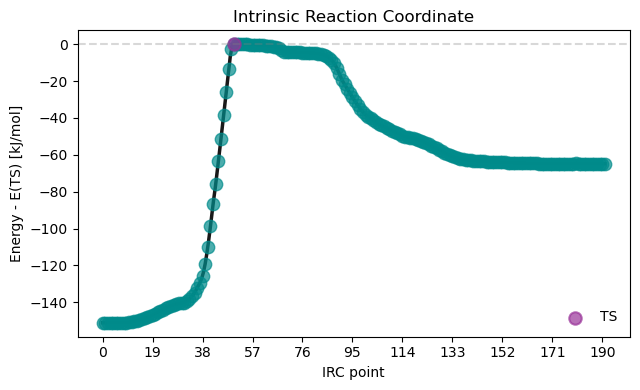

In [18]:
opt_drv.plot_irc(opt_results)

**Text file**
:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
dispersion: yes
@end

@optimize
irc: yes
@end

@molecule
charge: -1
multiplicity: 1
xyz:
...
@end
:::

(sec:ES-opt)=
## Excited state optimization

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("bithiophene")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 2
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

grad_drv = vlx.TddftGradientDriver(scf_drv)
grad_drv.state_deriv_index = 1

opt_drv = vlx.OptimizationDriver(grad_drv)
opt_results = opt_drv.compute(molecule, basis, scf_drv, rsp_drv, rsp_results)


Reading bithiophene from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct In

In [2]:
molecule_opt = vlx.Molecule.read_xyz_string(opt_results['final_geometry'])
molecule_opt.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Text file**

To optimize an excited state, you need to use the task optimize and to specify which state you want to optimize with the `state_deriv_index:` keyword in the `@gradient` section.

:::{code}
@jobs
task: optimize
@end

@response
property: absorption
nstates: 2
@end

@gradient
state_deriv_index: 1
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

:::{figure} ../images/bithio-S1-opt.gif
:width: 400px
:align: center

Figure: Optimization of the molecular structure in the excited state, S$_1$.
:::